In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00


In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 37.2 MB/s eta 0:00:00


In [ ]:
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [6]:
data = pd.read_csv("fake_news_data.csv")

In [7]:
data.head()

,title,text,date,fake_or_factual
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   title            198 non-null    object
 1   text             198 non-null    object
 2   date             198 non-null    object
 3   fake_or_factual  198 non-null    object
dtypes: object(4)
memory usage: 6.3+ KB


Text(0.5, 1.0, 'fake and factual')

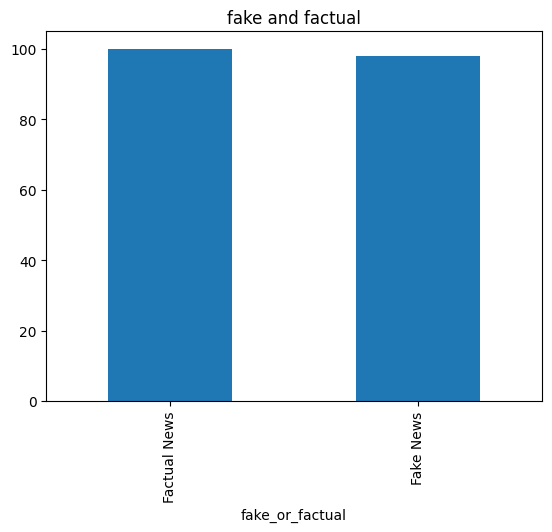

In [9]:
data['fake_or_factual'].value_counts().plot(kind='bar')
plt.title('fake and factual')

# POS Tagging

In [10]:
nlp=spacy.load('en_core_web_sm')

In [11]:
fake_news=data[data['fake_or_factual']=='Fake News']
fact_news=data[data['fake_or_factual']=='Factual News']

In [12]:
fake_spacydoc=list(nlp.pipe(fake_news['text']))
fact_spacydoc=list(nlp.pipe(fact_news['text']))

In [13]:
def extract_token_tags(doc:spacy.tokens.doc.Doc):
  return[(i.text,i.ent_type_,i.pos_)for i in doc]

In [14]:
fake_tagesdf=[]

columns = ['tokens', 'entity_type', 'pos_tag']

for ix,doc in enumerate(fake_spacydoc):
  tags=extract_token_tags(doc)
  tags=pd.DataFrame(tags)
  tags.columns = columns
  fake_tagesdf.append(tags)

fake_tagesdf=pd.concat(fake_tagesdf)

In [15]:
fact_tagsdf=[]

# Define column names for the DataFrame (consistent with fake_tagesdf)
columns = ['tokens', 'entity_type', 'pos_tag']

for ix ,doc in enumerate(fact_spacydoc):
  tags=extract_token_tags(doc)
  tags=pd.DataFrame(tags)
  tags.columns = columns # Assign the defined column names
  fact_tagsdf.append(tags)

fact_tagsdf=pd.concat(fact_tagsdf)

In [16]:
fake_tagesdf.head()

,tokens,entity_type,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [17]:
pos_counts_fake=fake_tagesdf.groupby(['tokens','pos_tag']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)
pos_counts_fake.head(10)

,tokens,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [18]:
pos_count_fact=fact_tagsdf.groupby(['tokens','pos_tag']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)
pos_count_fact.head(10)

,tokens,pos_tag,counts
6145,the,DET,1903
14,",",PUNCT,1698
21,.,PUNCT,1382
4716,of,ADP,884
1898,a,DET,789
2093,and,CCONJ,757
4005,in,ADP,671
6205,to,PART,660
4743,on,ADP,482
5567,said,VERB,451


In [19]:
pos_counts_fake.groupby('pos_tag')['tokens'].count().sort_values(ascending=False).head(10)

,tokens
pos_tag,
NOUN,2586
VERB,1817
PROPN,1672
ADJ,882
ADV,413
NUM,221
PRON,96
ADP,89
AUX,62


In [20]:
pos_count_fact.groupby('pos_tag')['tokens'].count().sort_values(ascending=False).head(10)

,tokens
pos_tag,
NOUN,2179
VERB,1539
PROPN,1379
ADJ,747
ADV,263
NUM,205
PRON,79
ADP,70
AUX,43


In [21]:
pos_count_fact[pos_count_fact.pos_tag=="NOUN"][0:15]

,tokens,pos_tag,counts
3738,government,NOUN,71
6618,year,NOUN,64
5901,state,NOUN,57
2360,bill,NOUN,55
1975,administration,NOUN,51
5066,president,NOUN,49
3277,election,NOUN,48
4919,people,NOUN,45
4786,order,NOUN,45
2497,campaign,NOUN,42


In [22]:
pos_counts_fake[pos_counts_fake.pos_tag=="NOUN"][0:15]

,tokens,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
8011,year,NOUN,44
3138,campaign,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


# Named Entity

In [23]:
top_entities_fake=fake_tagesdf[fake_tagesdf['entity_type'] != ""].groupby(['tokens','entity_type']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)

In [24]:
top_entities_fact=fact_tagsdf[fact_tagsdf['entity_type']!=""].groupby(['tokens','entity_type']).size().reset_index(name='counts').sort_values(by='counts',ascending=False)

In [25]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most Common Entities in Fake News')]

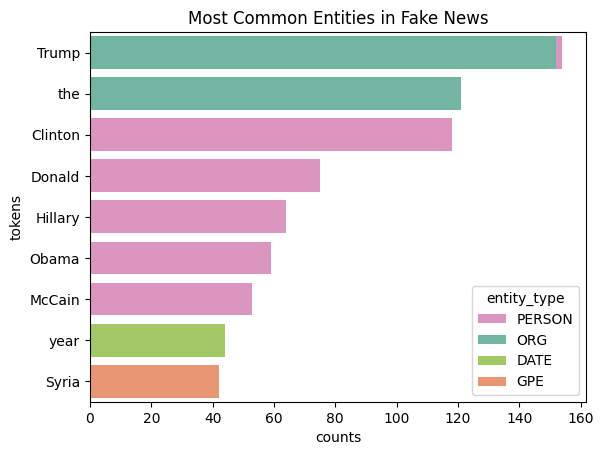

In [26]:
sns.barplot(
    x = 'counts',
    y = 'tokens',
    hue = 'entity_type',
    palette = ner_palette,
    data = top_entities_fake[0:10],
    orient = 'h',
    dodge=False
).set(title='Most Common Entities in Fake News')

[Text(0.5, 1.0, 'Most Common Entities in Fact News')]

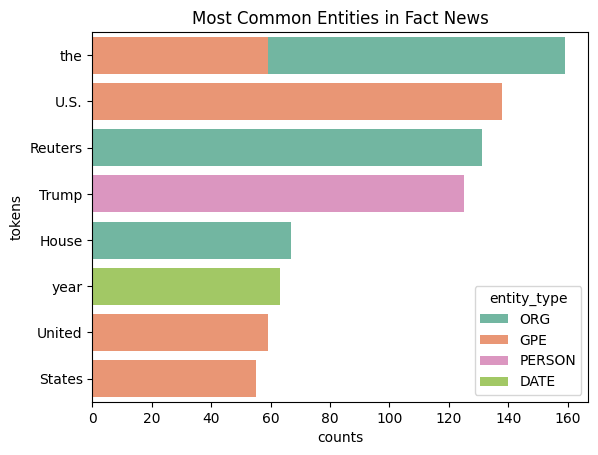

In [27]:
sns.barplot(
    x = 'counts',
    y = 'tokens',
    hue = 'entity_type',
    palette = ner_palette,
    data = top_entities_fact[0:10],
    orient = 'h',
    dodge=False
).set(title='Most Common Entities in Fact News')

# Data preprocessing

In [28]:
data['text_clean']=data.apply(lambda x :re.sub(r"^[^-]*-\s*","",x['text']),axis=1)

In [29]:
data['text_clean']=data['text_clean'].str.lower()

In [30]:
data['text_clean']=data.apply(lambda x:re.sub(r"([^\w\s])","",x['text_clean']),axis=1)

In [31]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [32]:
en_stopwords=stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [33]:
data['text_clean']=data['text_clean'].apply(lambda x:' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [34]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [35]:
data['text_clean']=data.apply(lambda x:word_tokenize(x['text_clean']),axis=1)

In [36]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [37]:
lemmatizer=WordNetLemmatizer()
data['text_clean']=data['text_clean'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [38]:
data.head()

,title,text,date,fake_or_factual,text_clean
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[yearold, oscarwinning, actress, described, me..."
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,..."
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u..."
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon..."
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,..."


In [39]:
from pandas.core import series
tokens_clean=sum(data['text_clean'],[])
unigrams =(pd.Series(nltk.ngrams(tokens_clean,1)).value_counts()).reset_index()[:10]
print(unigrams)

           index  count
0        (said,)    560
1       (trump,)    520
2           (u,)    255
3       (state,)    250
4   (president,)    226
5       (would,)    210
6         (one,)    141
7  (republican,)    128
8        (year,)    128
9        (also,)    124


[Text(0.5, 1.0, 'Most Common Unigrams After Preprocessing')]

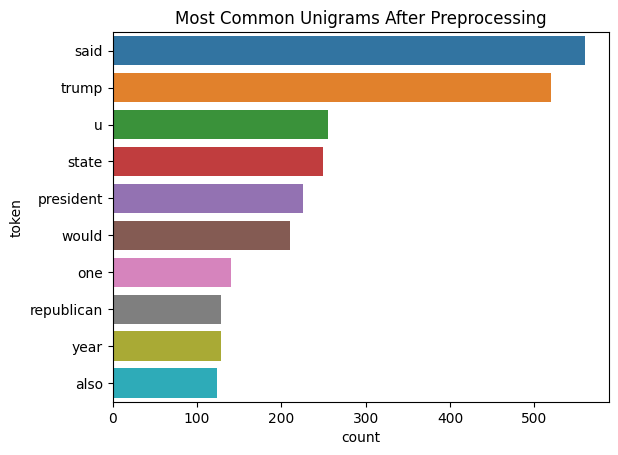

In [40]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0]) # extract the token from the tuple so we can plot it

sns.barplot(x = "count",
            y = "token",
            data=unigrams,
            orient = 'h',
            hue = "token", legend = False)\
.set(title='Most Common Unigrams After Preprocessing')

In [41]:
bigrams = (pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts())
print(bigrams[:10])

(donald, trump)            92
(united, state)            80
(white, house)             72
(president, donald)        42
(hillary, clinton)         31
(new, york)                31
(image, via)               29
(supreme, court)           29
(official, said)           26
(trump, administration)    24
Name: count, dtype: int64


# Sentiment Analysis

In [42]:
vadar_sentiment =SentimentIntensityAnalyzer()

In [43]:
data['vadar_sentiment_score']=data['text'].apply(lambda reviews:vadar_sentiment.polarity_scores(reviews)['compound'])

<Axes: xlabel='vadar_sentiment_label'>

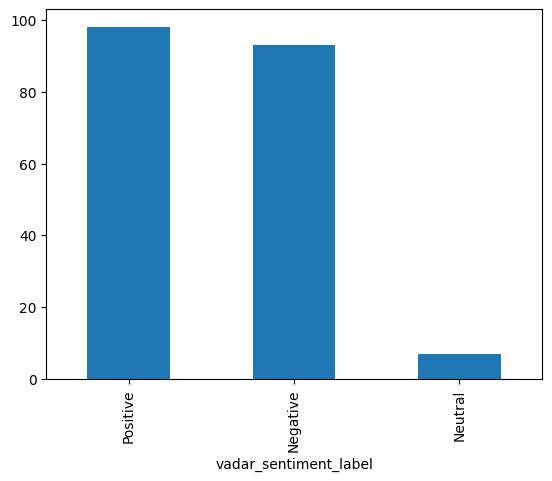

In [44]:
bins=[-1,-0.1,0.1,1]
names=['Negative','Neutral','Positive']
data['vadar_sentiment_label']=pd.cut(data['vadar_sentiment_score'],bins,labels=names)
data['vadar_sentiment_label'].value_counts().plot.bar()


/tmp/ipykernel_6125/1136321239.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

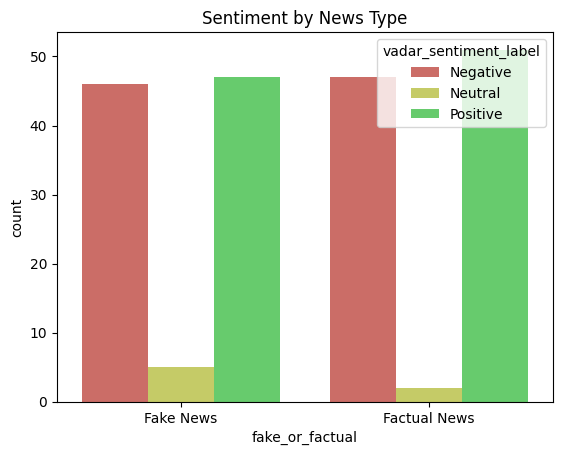

In [45]:
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vadar_sentiment_label',
    palette = sns.color_palette("hls"),
    data = data
).set(title='Sentiment by News Type')

# LDA

In [46]:
fake_news_text=data[data['fake_or_factual']=='Fake News']['text_clean'].reset_index(drop=True)
dictionary_fake=corpora.Dictionary(fake_news_text)
doc_term_fake=[dictionary_fake.doc2bow(text) for text in fake_news_text]

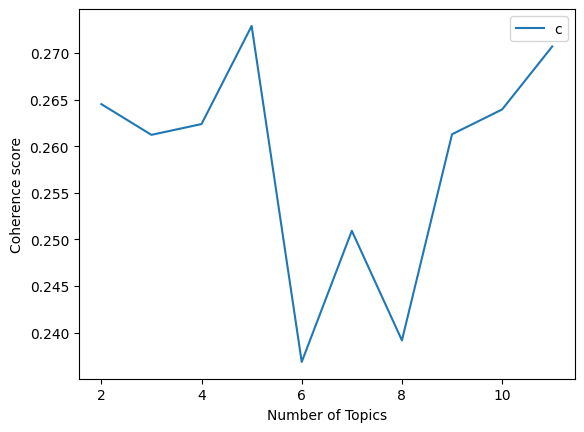

In [47]:
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = gensim.models.LdaModel(doc_term_fake, num_topics=num_topics_i, id2word = dictionary_fake)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=fake_news_text, dictionary=dictionary_fake, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [48]:
num_topics_fake = 6

lda_model_fake = gensim.models.LdaModel(corpus=doc_term_fake,
                                       id2word=dictionary_fake,
                                       num_topics=num_topics_fake)

lda_model_fake.print_topics(num_topics=num_topics_fake, num_words=10)

[(0,
  '0.017*"trump" + 0.005*"republican" + 0.005*"said" + 0.005*"would" + 0.005*"clinton" + 0.004*"one" + 0.003*"image" + 0.003*"president" + 0.003*"people" + 0.003*"u"'),
 (1,
  '0.007*"trump" + 0.003*"republican" + 0.003*"president" + 0.003*"state" + 0.003*"clinton" + 0.003*"people" + 0.003*"time" + 0.002*"said" + 0.002*"go" + 0.002*"woman"'),
 (2,
  '0.009*"trump" + 0.006*"clinton" + 0.005*"said" + 0.005*"president" + 0.004*"state" + 0.004*"one" + 0.004*"would" + 0.004*"u" + 0.004*"woman" + 0.004*"student"'),
 (3,
  '0.009*"trump" + 0.004*"said" + 0.004*"one" + 0.003*"state" + 0.003*"mccain" + 0.003*"president" + 0.003*"time" + 0.003*"go" + 0.003*"clinton" + 0.003*"would"'),
 (4,
  '0.014*"trump" + 0.004*"donald" + 0.003*"food" + 0.003*"president" + 0.003*"u" + 0.003*"time" + 0.003*"clinton" + 0.003*"news" + 0.003*"know" + 0.003*"said"'),
 (5,
  '0.007*"trump" + 0.006*"said" + 0.005*"state" + 0.004*"president" + 0.004*"time" + 0.004*"u" + 0.003*"would" + 0.003*"woman" + 0.003*"oba

# TF-IDF & LSA

In [49]:
def tfidf_corpus(doc_term_matrix):
    # create a corpus using tfidf vecotization
    tfidf = TfidfModel(corpus=doc_term_matrix, normalize=True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf

In [50]:
def get_coherence_scores(corpus, dictionary, text, min_topics, max_topics):
    # generate coherence scores to determine an optimum number of topics
    coherence_values = []
    model_list = []
    for num_topics_i in range(min_topics, max_topics+1):
        model = LsiModel(corpus, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
        model_list.append(model)
        coherence_model = CoherenceModel(model=model, texts=text, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherence_model.get_coherence())
    # plot results
    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("coherence_values"), loc='best')
    plt.show()

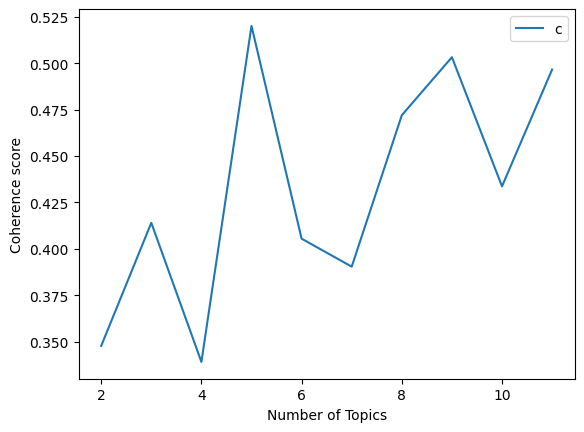

In [51]:
# create tfidf representation
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)
# coherence scores for fake news data
get_coherence_scores(corpus_tfidf_fake, dictionary_fake, fake_news_text, min_topics=2, max_topics=11)

In [52]:
lsa_fake = LsiModel(corpus_tfidf_fake, id2word=dictionary_fake, num_topics=5)
lsa_fake.print_topics()

[(0,
  '-0.218*"trump" + -0.135*"clinton" + -0.094*"woman" + -0.087*"president" + -0.086*"republican" + -0.085*"obama" + -0.084*"party" + -0.083*"school" + -0.081*"said" + -0.079*"time"'),
 (1,
  '-0.299*"boiler" + -0.253*"room" + -0.250*"acr" + -0.186*"jay" + -0.185*"animal" + -0.176*"episode" + -0.147*"analysis" + -0.122*"dyer" + -0.119*"corner" + -0.119*"evangelist"'),
 (2,
  '0.219*"school" + -0.195*"clinton" + -0.163*"conference" + 0.151*"county" + 0.137*"student" + -0.120*"press" + -0.116*"trump" + -0.112*"hillary" + 0.101*"love" + -0.095*"email"'),
 (3,
  '-0.375*"flynn" + -0.151*"russian" + -0.111*"email" + -0.109*"30" + -0.101*"department" + -0.100*"information" + -0.100*"nana" + -0.099*"official" + -0.098*"mccain" + 0.096*"trump"'),
 (4,
  '0.235*"trump" + 0.223*"flynn" + 0.166*"conference" + -0.165*"clinton" + -0.153*"dnc" + -0.151*"sander" + -0.127*"email" + 0.111*"press" + -0.109*"rich" + 0.084*"tax"')]

# Predict fake or factual news

In [53]:
X = [','.join(map(str, l)) for l in data['text_clean']]
Y = data['fake_or_factual']

In [54]:
countvec = CountVectorizer()
countvec_fit = countvec.fit_transform(X)
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns = countvec.get_feature_names_out())

In [55]:
X_train, X_test, y_train, y_test = train_test_split(bag_of_words, Y, test_size=0.3)

In [56]:
lr = LogisticRegression(random_state=0).fit(X_train, y_train)

In [57]:
y_pred_lr = lr.predict(X_test)

In [58]:
accuracy_score(y_pred_lr, y_test)

0.8833333333333333

In [59]:
svm = SGDClassifier().fit(X_train, y_train)

In [60]:
y_pred_svm = svm.predict(X_test)

In [61]:
accuracy_score(y_pred_svm, y_test)

0.8166666666666667